<a href="https://colab.research.google.com/github/gbzgbs/northstar_dataset/blob/main/01_NorthStar_Operational_SQL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Operational Performance Analysis (SQL in R)
Identifing specific geographical bottlenecks in the delivery network by joining operational outcomes with initial order data.

In [11]:
# Clone GitHub repository to get the dataset
!git clone https://github.com/gbzgbs/northstar_dataset.git

fatal: destination path 'northstar_dataset' already exists and is not an empty directory.


In [12]:
# Enable R to run inside this Python notebook
%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [13]:
%%R
# Install and load the sqldf library
install.packages("sqldf", quiet=TRUE)
library(sqldf)

# Load the orders and deliveries datasets
orders <- read.csv("/content/northstar_dataset/orders.csv")
deliveries <- read.csv("/content/northstar_dataset/deliveries.csv")

print("Data loaded successfully! Ready to query.")

[1] "Data loaded successfully! Ready to query."


In [14]:
%%R
# Join the tables to find the worst-performing hubs
hub_performance <- sqldf("
  SELECT
    d.hub_id,
    COUNT(d.delivery_id) AS total_failures
  FROM
    orders o
  JOIN
    deliveries d ON o.order_id = d.order_id
  WHERE
    d.delivery_status IN ('Failed', 'Late')
  GROUP BY
    d.hub_id
  ORDER BY
    total_failures DESC
")

# Show the highest failing hubs
head(hub_performance)

  hub_id total_failures
1    H08             26
2    H05             23
3    H01             17
4    H04             16
5    H06             15
6    H07             14


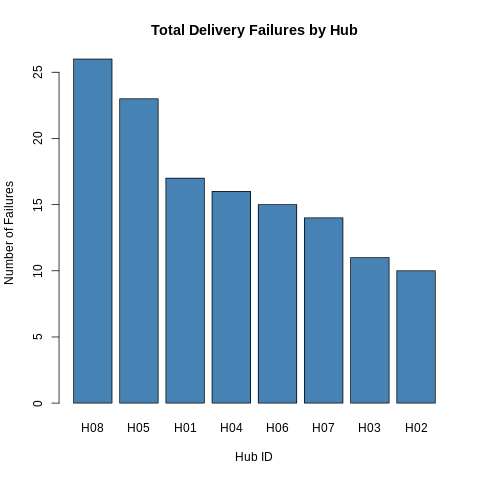

In [15]:
%%R
# This creates a simple bar chart from your hub_performance data
barplot(hub_performance$total_failures,
        names.arg = hub_performance$hub_id,
        main = "Total Delivery Failures by Hub",
        xlab = "Hub ID",
        ylab = "Number of Failures",
        col = "steelblue")